In [1]:
import sys
sys.path.append("../")

from src.data.load_data import load_all_data
from src.data.preprocess import preprocess_data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
data = load_all_data()

train = data["train"].copy()
features = data["features"].copy()
stores = data["stores"].copy()

INFO:src.data.load_data:train.csv loaded successfully with shape (421570, 5)
INFO:src.data.load_data:test.csv loaded successfully with shape (115064, 4)
INFO:src.data.load_data:features.csv loaded successfully with shape (8190, 12)
INFO:src.data.load_data:stores.csv loaded successfully with shape (45, 3)


In [2]:
train.head()
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [3]:
def audit(df, name):
    print(f"\n=== {name} ===")
    print("shape:", df.shape)
    print("\nmissing:\n", df.isnull().mean().sort_values(ascending=False).head(10))
    print("\ndtypes:\n", df.dtypes.value_counts())

In [4]:
audit(train, "train")


=== train ===
shape: (421570, 5)

missing:
 Store           0.0
Dept            0.0
Date            0.0
Weekly_Sales    0.0
IsHoliday       0.0
dtype: float64

dtypes:
 int64      2
object     1
float64    1
bool       1
Name: count, dtype: int64


In [5]:
audit(features, "features")


=== features ===
shape: (8190, 12)

missing:
 MarkDown2       0.643346
MarkDown4       0.577045
MarkDown3       0.558852
MarkDown1       0.507692
MarkDown5       0.505495
CPI             0.071429
Unemployment    0.071429
Store           0.000000
Fuel_Price      0.000000
Temperature     0.000000
dtype: float64

dtypes:
 float64    9
int64      1
object     1
bool       1
Name: count, dtype: int64


In [6]:
audit(stores, "stores")


=== stores ===
shape: (45, 3)

missing:
 Store    0.0
Type     0.0
Size     0.0
dtype: float64

dtypes:
 int64     2
object    1
Name: count, dtype: int64


In [7]:
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

In [8]:
audit(train, "train")
audit(features, "features")
audit(stores, "stores")


=== train ===
shape: (421570, 5)

missing:
 Store           0.0
Dept            0.0
Date            0.0
Weekly_Sales    0.0
IsHoliday       0.0
dtype: float64

dtypes:
 int64             2
datetime64[ns]    1
float64           1
bool              1
Name: count, dtype: int64

=== features ===
shape: (8190, 12)

missing:
 MarkDown2       0.643346
MarkDown4       0.577045
MarkDown3       0.558852
MarkDown1       0.507692
MarkDown5       0.505495
CPI             0.071429
Unemployment    0.071429
Store           0.000000
Fuel_Price      0.000000
Temperature     0.000000
dtype: float64

dtypes:
 float64           9
int64             1
datetime64[ns]    1
bool              1
Name: count, dtype: int64

=== stores ===
shape: (45, 3)

missing:
 Store    0.0
Type     0.0
Size     0.0
dtype: float64

dtypes:
 int64     2
object    1
Name: count, dtype: int64


In [9]:
df = (
    train
    .merge(features, on=["Store", "Date"], how="left")
    .merge(stores, on="Store", how="left")
)

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [10]:
df = df.rename(columns={"IsHoliday_x": "IsHoliday"})
df = df.drop(columns=["IsHoliday_y"])

## Global Demand Over Time

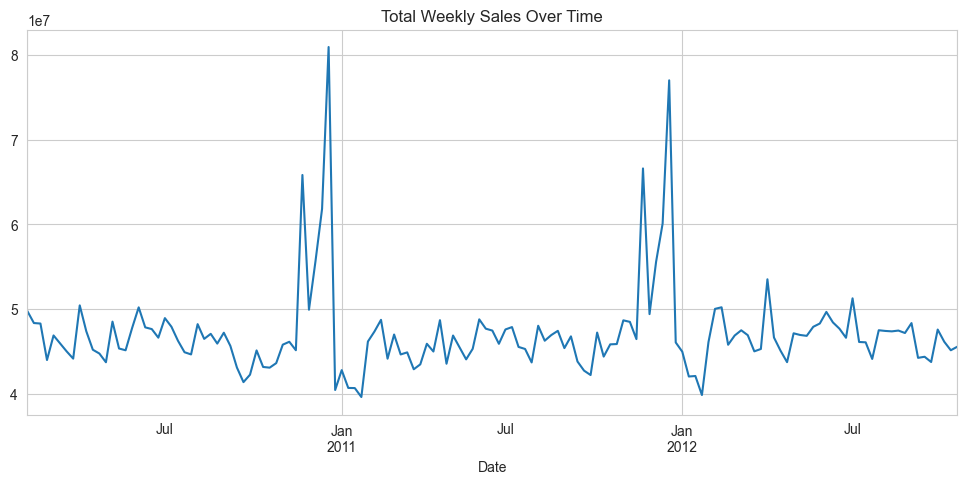

In [11]:
daily_sales = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(12, 5))
daily_sales.plot()
plt.title("Total Weekly Sales Over Time")
plt.show()

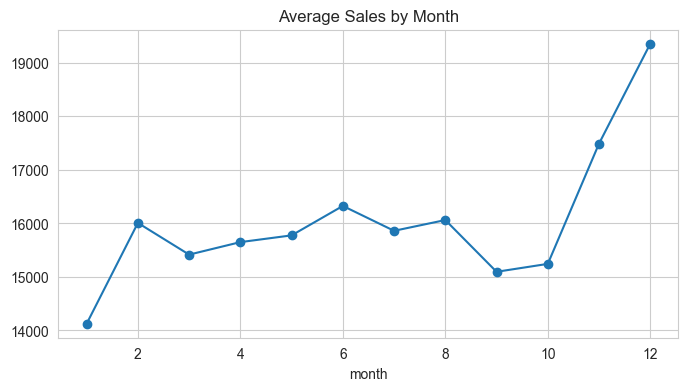

In [12]:
df["month"] = df["Date"].dt.month
df["week"] = df["Date"].dt.isocalendar().week.astype(int)

monthly = df.groupby("month")["Weekly_Sales"].mean()

plt.figure(figsize=(8,4))
monthly.plot(marker="o")
plt.title("Average Sales by Month")
plt.show()

## Store Heterogeneity

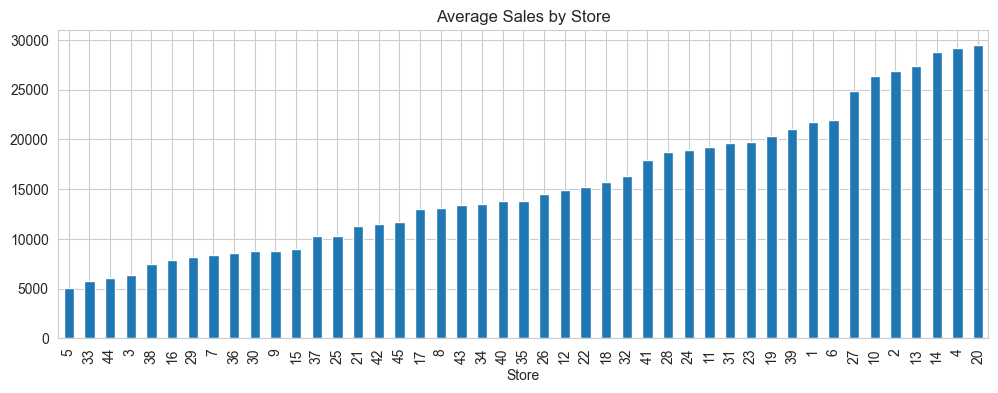

In [13]:
store_avg = df.groupby("Store")["Weekly_Sales"].mean()

plt.figure(figsize=(12,4))
store_avg.sort_values().plot(kind="bar")
plt.title("Average Sales by Store")
plt.show()

## External Features vs Sales

### Temperature

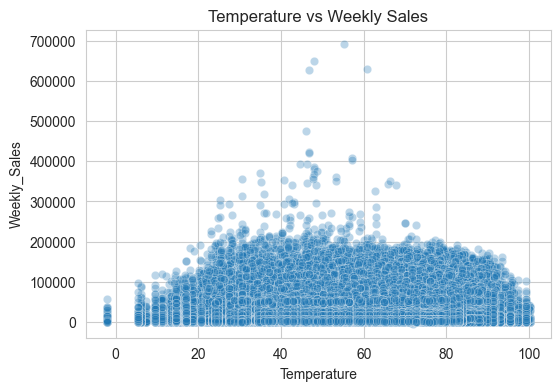

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["Temperature"], y=df["Weekly_Sales"], alpha=0.3)
plt.title("Temperature vs Weekly Sales")
plt.show()

### Fuel Price

<Axes: xlabel='Fuel_Price', ylabel='Weekly_Sales'>

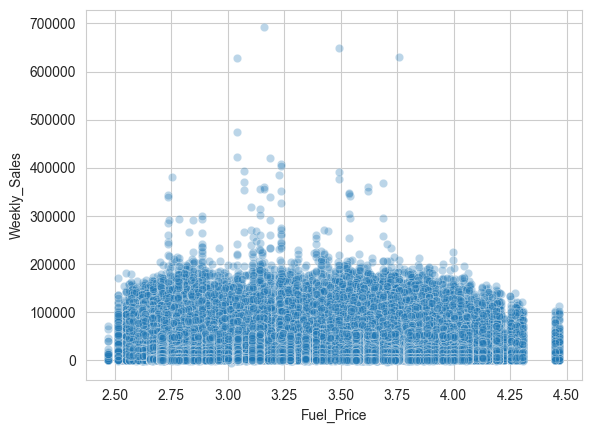

In [15]:
sns.scatterplot(x=df["Fuel_Price"], y=df["Weekly_Sales"], alpha=0.3)

### Correlation

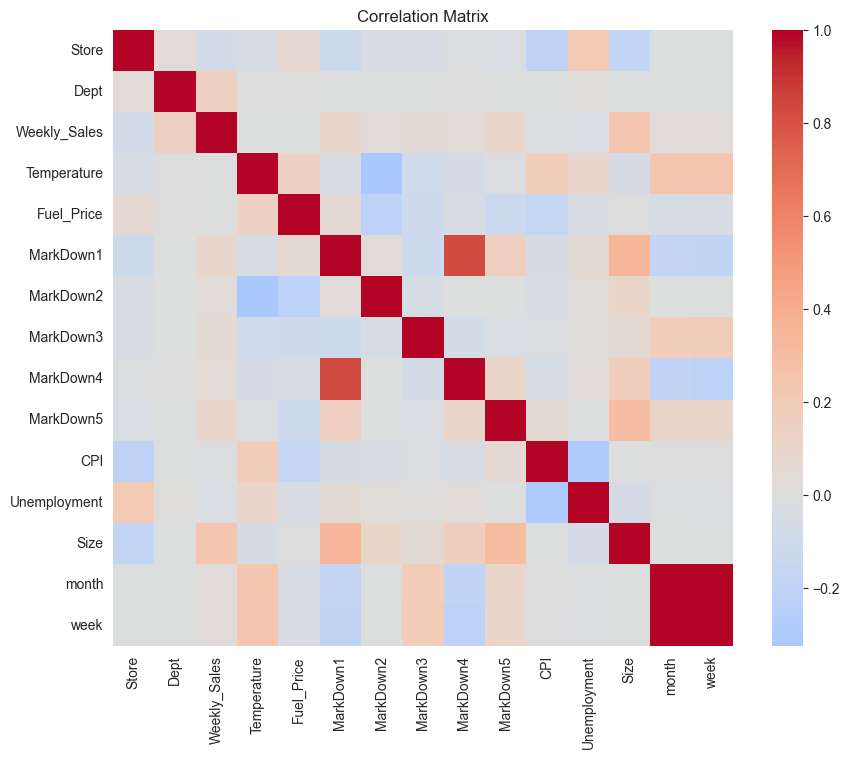

In [16]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

## Holiday Impact

In [17]:
holiday_effect = df.groupby("IsHoliday")["Weekly_Sales"].mean()
holiday_effect

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

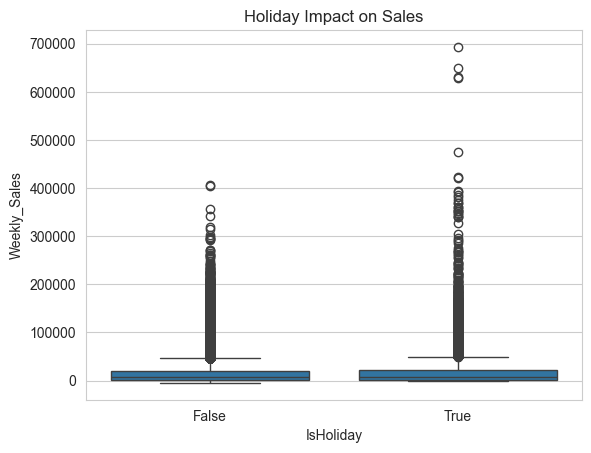

In [18]:
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=df)
plt.title("Holiday Impact on Sales")
plt.show()

## Missingness Pattern

In [19]:
missing_pct = df.isnull().mean().sort_values(ascending=False)
missing_pct.head(15)

MarkDown2       0.736110
MarkDown4       0.679847
MarkDown3       0.674808
MarkDown1       0.642572
MarkDown5       0.640790
Store           0.000000
Dept            0.000000
IsHoliday       0.000000
Temperature     0.000000
Date            0.000000
Fuel_Price      0.000000
Weekly_Sales    0.000000
CPI             0.000000
Unemployment    0.000000
Type            0.000000
dtype: float64

Text(0.5, 1.0, 'Store Size Distribution')

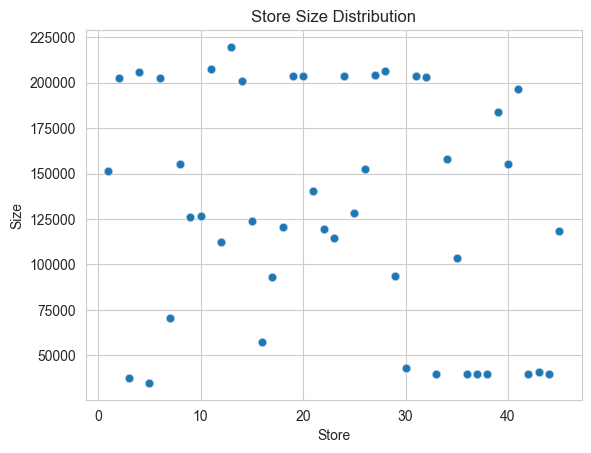

In [20]:
sns.scatterplot(x=df["Store"], y=df["Size"], alpha=0.3)
plt.title("Store Size Distribution")

In [21]:
df = preprocess_data()
df.head()

INFO:src.data.load_data:train.csv loaded successfully with shape (421570, 5)
INFO:src.data.load_data:test.csv loaded successfully with shape (115064, 4)
INFO:src.data.load_data:features.csv loaded successfully with shape (8190, 12)
INFO:src.data.load_data:stores.csv loaded successfully with shape (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,size_category
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,medium
143,1,2,2010-02-05,50605.27,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,medium
286,1,3,2010-02-05,13740.12,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,medium
429,1,4,2010-02-05,39954.04,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,medium
572,1,5,2010-02-05,32229.38,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,medium


In [24]:
df.to_csv("C:\\Users\\subhr\\Downloads\\demand-intelligence-system\\data\\processed\\cleaned_data.csv", index=False)